In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('car_data.csv')

In [4]:
df.head()

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


In [5]:
df.shape

(1000, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [7]:
# Check the duplicate values in the dataset
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

In [9]:
# drop user id column as it is not useful for analysis
df.drop('User ID', axis=1, inplace=True)

In [10]:
df.columns

Index(['Gender', 'Age', 'AnnualSalary', 'Purchased'], dtype='object')

In [11]:
df.describe()

,Age,AnnualSalary,Purchased
count,1000.000000,1000.000000,1000.000000
mean,40.106000,72689.000000,0.402000
std,10.707073,34488.341867,0.490547
min,18.000000,15000.000000,0.000000
25%,32.000000,46375.000000,0.000000
50%,40.000000,72000.000000,0.000000
75%,48.000000,90000.000000,1.000000
max,63.000000,152500.000000,1.000000


In [12]:
df['Gender'].value_counts()

Gender
Female    516
Male      484
Name: count, dtype: int64

<Axes: xlabel='AnnualSalary', ylabel='Count'>

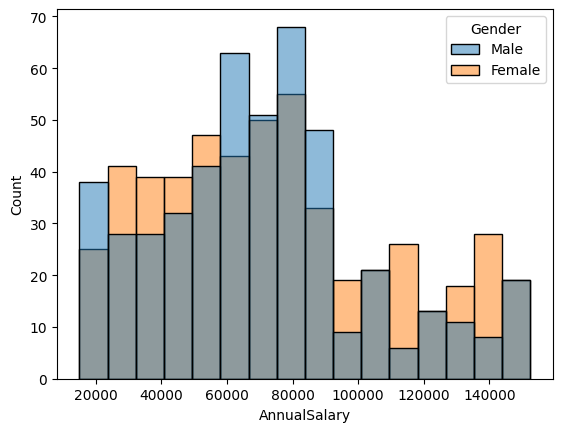

In [13]:
sns.histplot(x='AnnualSalary', data=df, hue='Gender')

<Axes: xlabel='Age', ylabel='Count'>

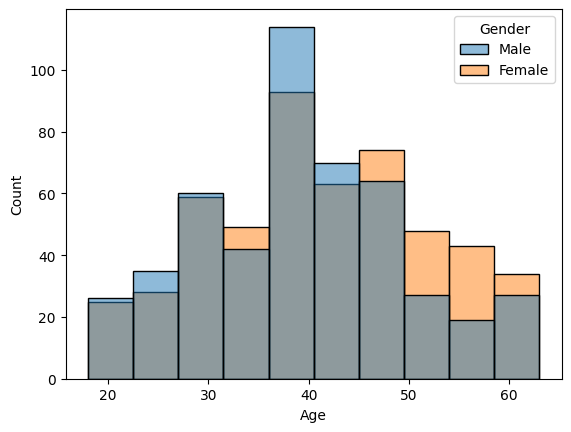

In [14]:
sns.histplot(data=df, x='Age', bins=10, hue='Gender')

<Axes: xlabel='AnnualSalary', ylabel='Count'>

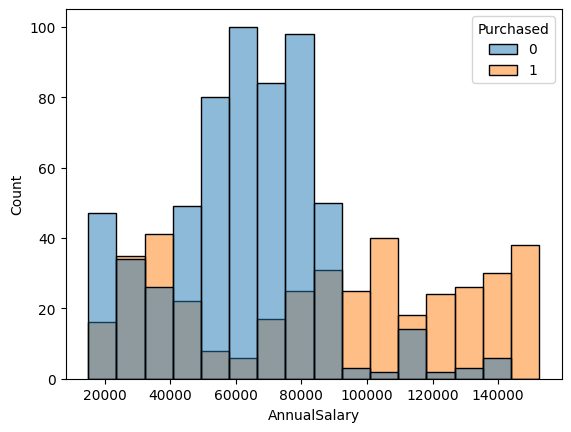

In [15]:
sns.histplot(data=df, x='AnnualSalary', hue='Purchased')

<Axes: xlabel='Age', ylabel='Count'>

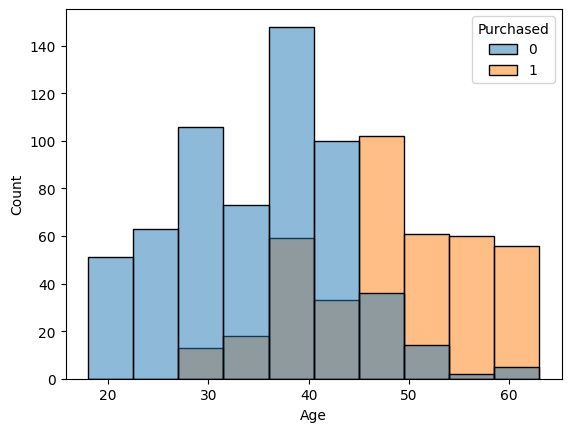

In [16]:
sns.histplot(data=df, x='Age', bins=10, hue='Purchased')

In [17]:
df.corr(numeric_only=True)['Purchased'].sort_values()

AnnualSalary    0.364974
Age             0.616036
Purchased       1.000000
Name: Purchased, dtype: float64

# Feature Engineer

In [18]:
df = pd.get_dummies(df, drop_first=False)
df.head()

,Age,AnnualSalary,Purchased,Gender_Female,Gender_Male
0,35,20000,0,False,True
1,40,43500,0,False,True
2,49,74000,0,False,True
3,40,107500,1,False,True
4,25,79000,0,False,True


In [19]:
df = df.drop('Gender_Male', axis = 'columns')

In [20]:
x = df[["AnnualSalary","Age","Gender_Female"]].copy()

In [21]:
y = df['Purchased'].copy()

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.3)

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_x_train = scaler.fit_transform(X_train)
scaled_x_test = scaler.fit_transform(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [25]:
def modelperformance(prediction):
    print('Accuracy Score: ', accuracy_score(y_test, prediction))
    print('Classification Report: \n', classification_report(y_test, prediction))
    print('Confusion Matrix: \n', confusion_matrix(y_test, prediction))

# Machine Learning

In [26]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(scaled_x_train, y_train)
log_prediction = log_model.predict(scaled_x_test)
modelperformance(log_prediction)

Accuracy Score:  0.8533333333333334
Classification Report: 
               precision    recall  f1-score   support

           0       0.85      0.92      0.88       181
           1       0.86      0.76      0.80       119

    accuracy                           0.85       300
   macro avg       0.85      0.84      0.84       300
weighted avg       0.85      0.85      0.85       300

Confusion Matrix: 
 [[166  15]
 [ 29  90]]


In [27]:
from sklearn.neighbors import KNeighborsClassifier
test_errors = []

for k in range(1, 30):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_x_train, y_train.values.ravel())
    knn_pred = knn_model.predict(scaled_x_test)
    test_error_rate = 1 - accuracy_score(y_test, knn_pred)
    test_errors.append(test_error_rate)

Text(0.5, 0, 'K Neighbors')

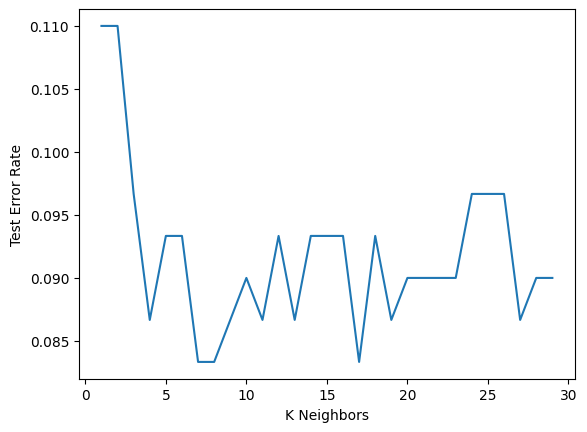

In [28]:
plt.plot(range(1, 30), test_errors)
plt.ylabel('Test Error Rate')
plt.xlabel('K Neighbors')

In [29]:
knn_elbowmethod = KNeighborsClassifier(n_neighbors=12)
knn_elbowmethod.fit(scaled_x_train, y_train.values.ravel())
knn_pred = knn_elbowmethod.predict(scaled_x_test)
modelperformance(knn_pred)

Accuracy Score:  0.9066666666666666
Classification Report: 
               precision    recall  f1-score   support

           0       0.94      0.90      0.92       181
           1       0.86      0.92      0.89       119

    accuracy                           0.91       300
   macro avg       0.90      0.91      0.90       300
weighted avg       0.91      0.91      0.91       300

Confusion Matrix: 
 [[163  18]
 [ 10 109]]


In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
k_values = list(range(1, 30))

pipe = Pipeline(steps=[('knn', knn)])

param_grid = {'knn__n_neighbors': k_values}

cv_classifier = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy")

cv_classifier.fit(scaled_x_train, y_train.values.ravel())
print(cv_classifier.best_params_)


{'knn__n_neighbors': 22}


In [31]:
pred_gridknn = cv_classifier.predict(scaled_x_test)
modelperformance(pred_gridknn)

Accuracy Score:  0.91
Classification Report: 
               precision    recall  f1-score   support

           0       0.94      0.91      0.92       181
           1       0.87      0.92      0.89       119

    accuracy                           0.91       300
   macro avg       0.90      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300

Confusion Matrix: 
 [[164  17]
 [ 10 109]]


In [32]:
from sklearn.svm import SVC
svm = SVC()
param_grid_svr = {"C":[0.01, 0.1, 0.5, 1], 'kernel':['linear', 'rbf', 'poly']}
gridsvr = GridSearchCV(svm, param_grid_svr)

In [33]:
gridsvr.fit(scaled_x_train, y_train.values.ravel())
pred_svr = gridsvr.predict(scaled_x_test)
modelperformance(pred_svr)

Accuracy Score:  0.91
Classification Report: 
               precision    recall  f1-score   support

           0       0.95      0.90      0.92       181
           1       0.86      0.92      0.89       119

    accuracy                           0.91       300
   macro avg       0.90      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300

Confusion Matrix: 
 [[163  18]
 [  9 110]]


In [34]:
from sklearn.tree import DecisionTreeClassifier
treemodel = DecisionTreeClassifier()
treemodel.fit(scaled_x_train, y_train.values.ravel())

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
print(gridsvr.best_params_)

{'C': 1, 'kernel': 'rbf'}


In [38]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(max_features=3, n_estimators=256, oob_score=True)